# Computational Linguistics Class 4: Dependencies and Visualizations
In this class, we will work with the `spacy` library to perform 

## ========== TASK 0 ===========
### Setup - Install packages and spacy model:
I didn't find any new dataset, that I liked, so we will return to our original `L2_Learner_Data.csv` from the first class.

We will be using **Pandas** and **Spacy** to perform our analysis, like we have done before.
We will also use matplotlib and seaborn to visualize our results.

In [133]:
# pip install spacy pandas matplotlib seaborn
# !python -m spacy download en_core_web_sm

# Import libraries
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## ========== TASK 1 ===========
### Load data, filter all rows with duplicate titles, and run spacy NLP parsing on `text` column:
When the dataset was orignially created, it was filtered so that would be 50 sentences from each cefr-level. This also means that some sentences come from the same original text. We are now so advanced, that we want to analyze the entire corpus. Therefore, we must filter all titles/texts that appear twice, to avoid using certain essays twice. Then process the `text`column using spaCy.


In [138]:
df = pd.read_csv("../data/L2_Learner_Data.csv")
df.shape
# Remove duplicate titles:
df = df.drop_duplicates(subset="title")
df.shape

(211, 9)

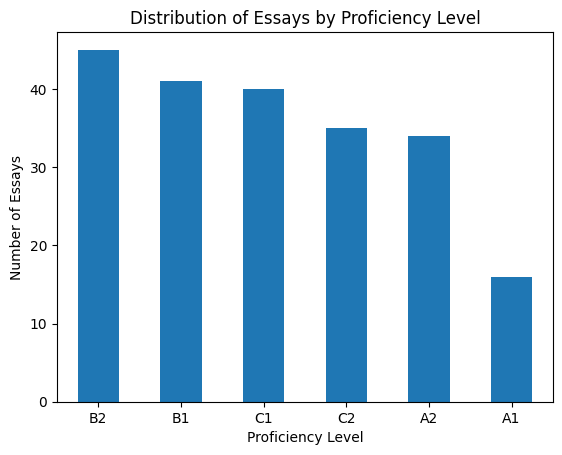

In [139]:
# Group by proficiency level and count the number of essays in each level
proficiency_counts = df["cefr_level"].value_counts().reset_index()
proficiency_counts.columns = ["proficiency_level", "count"]
proficiency_counts.plot(kind="bar", x="proficiency_level", y="count", legend=False)
plt.xlabel("Proficiency Level")
plt.ylabel("Number of Essays")
plt.title("Distribution of Essays by Proficiency Level")
plt.xticks(rotation=0)
plt.show()

In [140]:
import spacy
nlp = spacy.load("en_core_web_sm") # This is our natrual language processing object.

# Use a spacy pipe to process the data:
texts = df["text"].tolist()
cefr_level = df["cefr_level"].tolist()
doc_ids = df["title"].tolist()
docs = list(nlp.pipe(texts))


# Create a dataframe of the spacy docs and the corresponding proficiency levels:
cefr_data = pd.DataFrame({
    "doc_id": doc_ids,
    "cefr_level": cefr_level,
    "text": texts,
    "docs": docs,
})
cefr_data.head()

,doc_id,cefr_level,text,docs
0,0002.xml,A1,My family is very small. I have a big borther....,"(My, family, is, very, small, ., I, have, a, b..."
1,0423.xml,A1,I haven't many hobbies. I'm working like teach...,"(I, have, n't, many, hobbies, ., I, 'm, workin..."
2,0430.xml,A1,"My family is happy , it is a beautiful family....","(My, family, is, happy, ,, it, is, a, beautifu..."
3,0434.xml,A1,I usually get up at 7:00 in the morning. I hav...,"(I, usually, get, up, at, 7:00, in, the, morni..."
4,0436.xml,A1,We are three at home. My daughter have 15 yea...,"(We, are, three, at, home, ., , My, daughter,..."


## ========== TASK 2 ===========
### Find the mean dependency distance for each text in the corpus:
**Step 1:**
Visalise the sentence *"Today I want to become an expert in dependency parsing."* to get a visual feeling of the dependency grammar.

**Step 2:**
Create a dataframe to understand how the underlying information is represented. How would you calculate dependency distance?

**Step 3:**
Write a function that automatically calculates the Mean dependency distance (MDD) per text.
The function should take a spacy doc as input, and return a number equal to the MDD. If you get stuck, feel free to look up solutions, raise your hand or ask a classmate.

**Step 4:** 
Apply this function on all texts from the L2_Learner_Data


### Step 1:

In [141]:
# Visualize the depency grammar for the sentence:
example = nlp("You must master a sentence before you conquer the corpus.")

spacy.displacy.render(example, style="dep", jupyter=True)

### Step 2:

In [142]:
# Make a dataframe of the depenencies in the sentence:
dep_df = pd.DataFrame({
    "index": [token.i for token in example],
    "token": [token.text for token in example],
    "dep": [token.dep_ for token in example],
    "head": [token.head.text for token in example],
    "head_index": [token.head.i for token in example],
    "diff": [abs(token.i - token.head.i) for token in example]
})
dep_df

,index,token,dep,head,head_index,diff
0,0,You,nsubj,master,2,2
1,1,must,aux,master,2,1
2,2,master,ROOT,master,2,0
3,3,a,det,sentence,4,1
4,4,sentence,dobj,master,2,2
5,5,before,mark,conquer,7,2
6,6,you,nsubj,conquer,7,1
7,7,conquer,advcl,master,2,5
8,8,the,det,corpus,9,1
9,9,corpus,dobj,conquer,7,2


> **Discussion**: What is the dependency distance for "master", "concquer" and "punct"? Do we want to include these in our dependency distance function?

### Step 3:
You need to write the function yourself. Think about what `token.i` and `token.head.i`is.

You can use the function `abs()` to take the abolute value of a number, i.e. abs(-1) == 1, abs(1) == 1

In [ ]:
# Create a mean dependency distance function:
def mean_dependency_distance(doc):
    # Write a for loop to calculate the dependency distance for each token in the doc:
    # If you want to exclude punctuations, you can use the following condition:
    # if token.dep_ != "punct":

    # Save your mean dependency distance in a variable called MDD and return it at the end of the function.
    
    return MDD

In [147]:
# Calculate mean dependency distance for the example sentence and see if it matches our intuition:
manual_mean = (2+1+1+2+2+1+5+1+2)/10
print(f"My manual computation of the mean dependency distance is (excluding punctuations): {manual_mean:.2f}")
print(f"Mean dependency distance computed by the function: {mean_dependency_distance(example):.2f}")

My manual computation of the mean dependency distance is (excluding punctuations): 1.70
Mean dependency distance computed by the function: 1.70


**You will now apply your function on the dataframe we created earlier.**

We have already used the spacy pipeline on the text and saved it in the `docs` column. Display the head of the dataframe below to get a reminder.

In [148]:
cefr_data.head()

,doc_id,cefr_level,text,docs
0,0002.xml,A1,My family is very small. I have a big borther....,"(My, family, is, very, small, ., I, have, a, b..."
1,0423.xml,A1,I haven't many hobbies. I'm working like teach...,"(I, have, n't, many, hobbies, ., I, 'm, workin..."
2,0430.xml,A1,"My family is happy , it is a beautiful family....","(My, family, is, happy, ,, it, is, a, beautifu..."
3,0434.xml,A1,I usually get up at 7:00 in the morning. I hav...,"(I, usually, get, up, at, 7:00, in, the, morni..."
4,0436.xml,A1,We are three at home. My daughter have 15 yea...,"(We, are, three, at, home, ., , My, daughter,..."


In [149]:
# Calculate mean dependency distance for all sentences in the dataset:
cefr_data["mean_dependency_distance"] = cefr_data["docs"].apply(lambda docs: mean_dependency_distance(docs))
cefr_data.head()

,doc_id,cefr_level,text,docs,mean_dependency_distance
0,0002.xml,A1,My family is very small. I have a big borther....,"(My, family, is, very, small, ., I, have, a, b...",1.200000
1,0423.xml,A1,I haven't many hobbies. I'm working like teach...,"(I, have, n't, many, hobbies, ., I, 'm, workin...",2.439394
2,0430.xml,A1,"My family is happy , it is a beautiful family....","(My, family, is, happy, ,, it, is, a, beautifu...",1.580645
3,0434.xml,A1,I usually get up at 7:00 in the morning. I hav...,"(I, usually, get, up, at, 7:00, in, the, morni...",1.525000
4,0436.xml,A1,We are three at home. My daughter have 15 yea...,"(We, are, three, at, home, ., , My, daughter,...",1.688889


## ========== TASK 3 ===========
### We will not use a violin plot to visualize the data
A violin plot mixes a boxplot with a density distribution. It gives is us the same statistical information as boxplot, but also gives an intuition about the distribution of the data.

This is where we will use seaborn and matplotlib. Two very popular plotting libraries in python.

There is a task inbetween the two python chunks, where you need to write a short explanation of the plots.

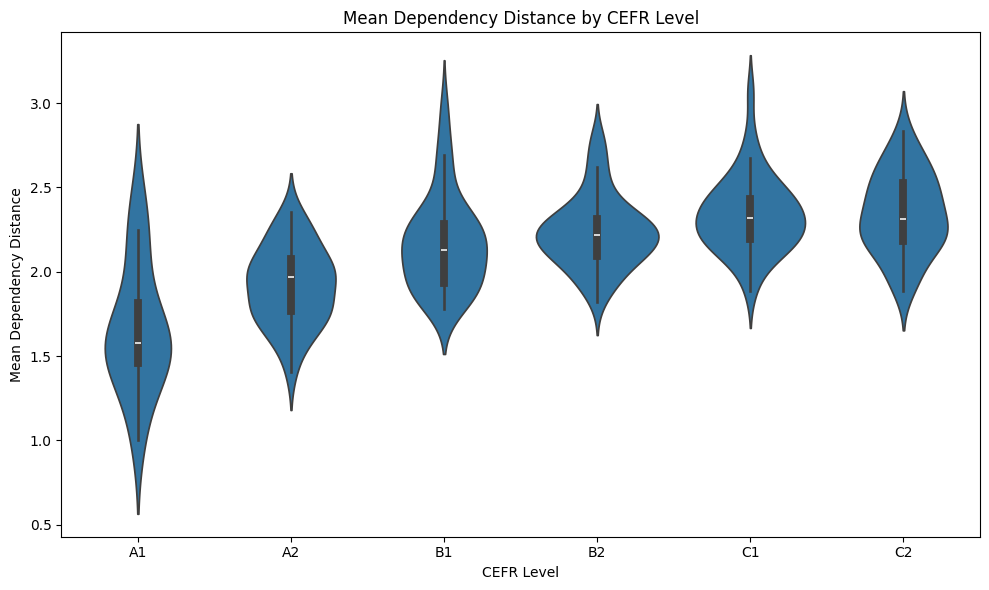

In [150]:
plt.figure(figsize=(10, 6))
level_order = ["A1", "A2", "B1", "B2", "C1", "C2"] # Define the order of CEFR levels

sns.violinplot(
    data=cefr_data, # This is the dataframe we are using for the plot.
    x="cefr_level", # This is the column we want to use for the x-axis.
    y="mean_dependency_distance", # This is the column we want to use for the y-axis.
    order=level_order # This is the order we want to use for the x-axis categories.
)

plt.title("Mean Dependency Distance by CEFR Level")
plt.xlabel("CEFR Level")
plt.ylabel("Mean Dependency Distance")
plt.tight_layout()
plt.show()

**Please give a short explanation of what the plot depicts:**

**Try and plot the average sentence length in the chunk below, how does MDD differ from average sentence length?**


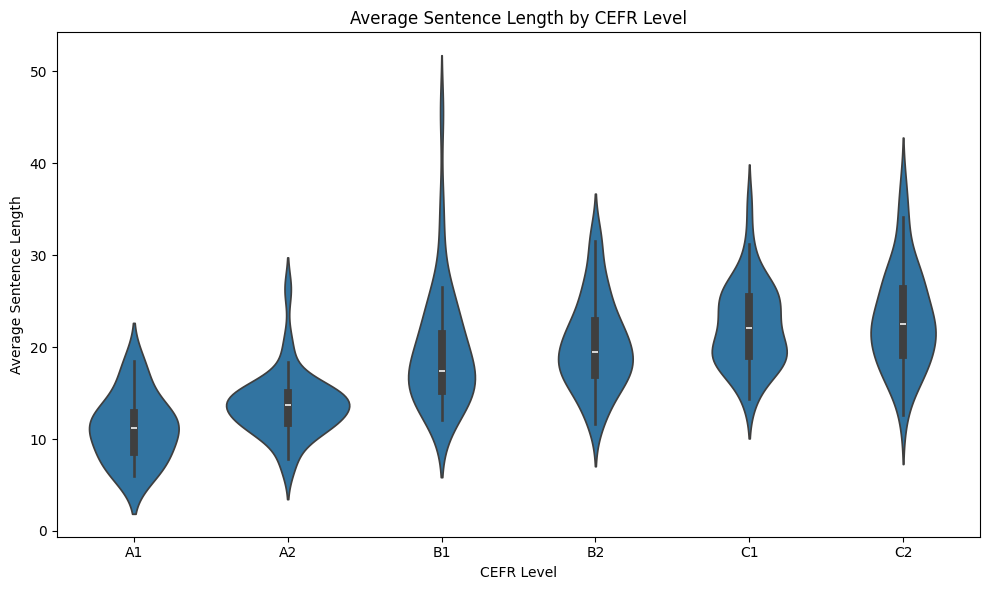

In [151]:
# Violin plot of average sentence length by CEFR level:
cefr_data["avg_sentence_length"] = cefr_data["docs"].apply(lambda doc: sum(len(sent) for sent in doc.sents) / len(list(doc.sents))) # Read as: "For all docs, sum the length of sentences in that document, and divide by the number of sentences in that document."
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=cefr_data, # This is the dataframe we are using for the plot.
    x="cefr_level", # This is the column we want to use for the x-axis.
    y="avg_sentence_length", # This is the column we want to use for the y-axis.
    order=level_order # This is the order we want to use for the x-axis categories.
)
plt.title("Average Sentence Length by CEFR Level")
plt.xlabel("CEFR Level")
plt.ylabel("Average Sentence Length")
plt.tight_layout()
plt.show()

## ========== TASK 4 ===========
### Plot a scatterplot of MDD and Sentence Length to investigate the correlation visually:
Scatterplots are a two-dimensional plot, where each point denotes a datapoint.
It can be used to show the visual correlation between two variables.

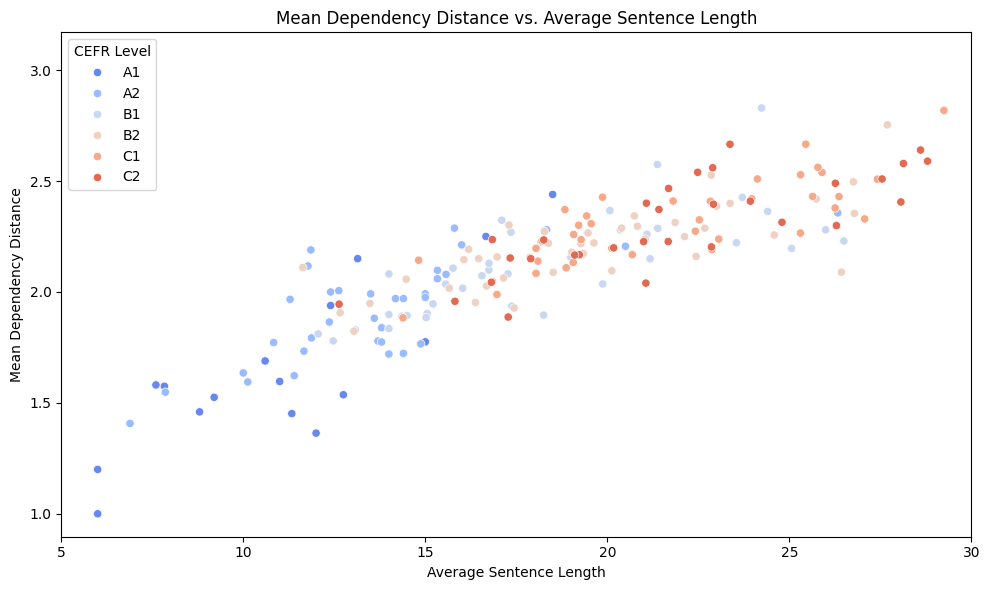

In [153]:
# Plot a scatteplot of mean dependency distance vs. average sentence length, colored by CEFR level:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=cefr_data,
    x="avg_sentence_length", # This is the column we want to use for the x-axis.
    y="mean_dependency_distance", # This is the column we want to use for the y-axis.
    hue="cefr_level", # This is the column we want to use for coloring the points.
    # A gradient palette can show the nominal order of cefr levels:
    palette=sns.color_palette("coolwarm", n_colors=len(level_order)),
)
plt.title("Mean Dependency Distance vs. Average Sentence Length")
plt.xlabel("Average Sentence Length")
plt.ylabel("Mean Dependency Distance")
plt.legend(title="CEFR Level")
plt.xlim(5, 30) # Can you figure out what this line does? try changing the numbers.
plt.tight_layout()
plt.show()

> **Extra Challenge**: 
If you think the previous tasks has been to much plug-and-play. Try and reproduce scatterplot above on a sentence level.
You can access the sentences and their cefr_level with:
```python
for essay, cefr_level in zip(cefr_data["docs"], cefr_data["cefr_level"]):
    for sentence in essay.sents:
        print(cefr_level)
        print(sentence) 
```
Then you can use your MDD function and the `len(sentence)` to get MDD and sentence length.

## ========== TASK 5 ===========
### This one is optional, but highly encouraged:
1. Find a linguistic construction, including either POS-tagging, Morphological features or Dependency information. 
2. Write a function that computes to what extend this feature is present in the data.
3. Make a visalisation of the result in python: Histogram (good for counts), Boxplot (provides statistical information), Distribution (good for continous numeric values), Violinplot (mix of distribution and boxplot), Scatterplot (good for comparing two variables) or whatever you want.

*Inspiration (from a non-linguist):*

- Does noun-phrases increase in length with higher CEFR-levels? Does the relative distribution of pre-modfiers and post-modifiers change as noun-phrases increase in length?
- In the case of subject–verb–object order structures, is the dependency distance on average longer between subject-verb or verb-object?
- Your own cool idea!